# Image Colour Quantisation using K-means Clustering

This notebook demonstrates colour quantisation of an image using K-means clustering,
reducing the image from millions of possible colours to just 16 colours while
preserving the main visual features. The process involves:
1. Converting the image into a collection of RGB points
2. Clustering these points in RGB space
3. Replacing each pixel's colour with its cluster centre
4. Reconstructing the image with the reduced colour palette

The visualisation shows both the clustering in RGB space and the
resulting recoloured image.

## Load Image and Prepare Data

The image is read as an (H, W, 3) array of RGB values and flattened to an
(N, 3) pixel array so each row is one RGB colour sample.

In [1]:
from matplotlib.image import imread
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans

# Load image and prepare data
image = imread("StillLife.jpg")
pixels = image.reshape(-1, image.shape[2])  # Flatten to pixel array

## Helper: Plot Colour Distribution

This function samples pixels and plots their distribution in Red–Green and
Red–Blue planes, coloured by either the original or the quantised palette.

In [2]:
def plot_colors(data, title, colors=None, samples=10000):
    # Sample random pixels for visualization
    if colors is None:
        colors = data

    rng = np.random.RandomState(0)
    indices = rng.permutation(len(data))[:samples]

    R, G, B = data[indices].T  # Extract RGB components
    norm_colors = colors[indices]/255  # Normalize colors

    # Create side-by-side scatterplots
    fig, ax = plt.subplots(1, 2)
    ax[0].scatter(R, G, c=norm_colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 255), ylim=(0, 255))

    ax[1].scatter(R, B, c=norm_colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 255), ylim=(0, 255))

    fig.suptitle(title, size=20)
    plt.show()

## Original Colour Distribution

Before quantisation, the scatter plot shows the full spread of the image's
~16 million possible RGB colours.

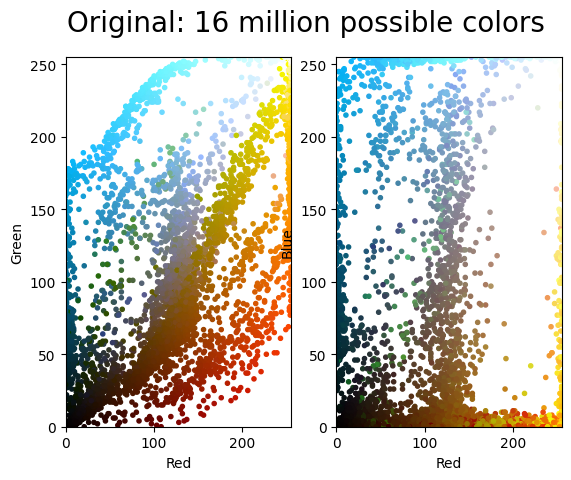

In [3]:
# Show original colors
plot_colors(pixels, title='Original: 16 million possible colors')

## Colour Quantisation with K-means

`MiniBatchKMeans` is used for efficiency on large pixel arrays. Each pixel is
reassigned to the colour of its nearest cluster centre, reducing the palette to 16 colours.

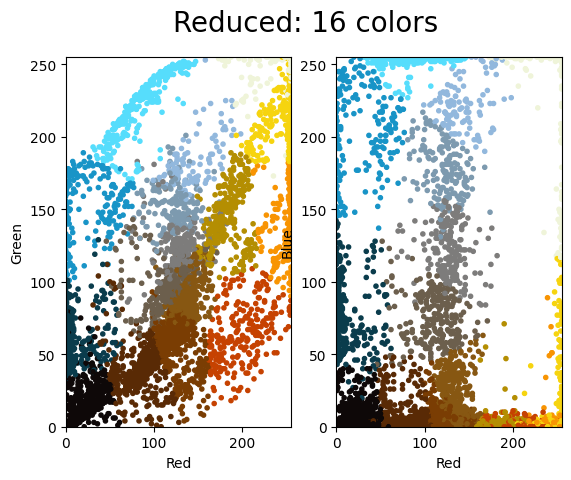

In [4]:
# Perform color quantization with K-means
kmeans = MiniBatchKMeans(n_clusters=16)
kmeans.fit(pixels)
reduced_colors = kmeans.cluster_centers_[kmeans.predict(pixels)].astype(int)

# Show reduced color distribution
plot_colors(pixels, colors=reduced_colors, title="Reduced: 16 colors")

## Compare Original and Recoloured Images

The quantised pixel array is reshaped back to the original image dimensions
and displayed alongside the original for a direct comparison.

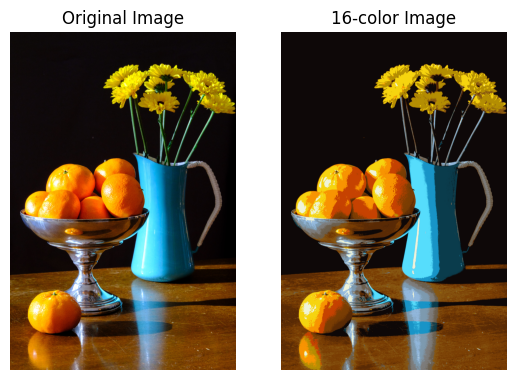

In [7]:
# Compare original and recolored images
recolored = reduced_colors.reshape(image.shape)
fig, ax = plt.subplots(1, 2)
ax[0].imshow(image)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(recolored)
ax[1].axis('off')
ax[1].set_title('16-color Image')
plt.show()